# MovieLens Data Analysis with Pandas

This notebook explores a MovieLens dataset using **Pandas**. We will load the CSV files, inspect the data, calculate descriptive statistics, handle missing values, visualize ratings, filter rows, group records, and merge DataFrames.

## Before you begin

Place the three CSV files (`movie.csv`, `rating.csv`, and `tag.csv`) in a folder named `Datasets` next to this notebook. If your files are stored elsewhere, update the file paths in the next section.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the datasets

`pd.read_csv()` reads a CSV file into a DataFrame. We load the movies, ratings, and tags data separately so we can explore how each table is structured.


In [2]:
movies = pd.read_csv(r"C:\Users\zeesh\Full_Stack_Data_Science_with_AI\03_Data_Analysis\07_Kaggle\Datasets\movie.csv")
ratings = pd.read_csv(r"C:\Users\zeesh\Full_Stack_Data_Science_with_AI\03_Data_Analysis\07_Kaggle\Datasets\rating.csv")
tags = pd.read_csv(r"C:\Users\zeesh\Full_Stack_Data_Science_with_AI\03_Data_Analysis\07_Kaggle\Datasets\tag.csv")

In [3]:
movies.shape

(27278, 3)

In [4]:
ratings.shape

(20000263, 4)

In [5]:
ratings.shape

(20000263, 4)

In [6]:
tags.shape

(465564, 4)

In [7]:
tags.shape

(465564, 4)

## 2. Inspect the data

Start by checking column names, sample rows, index labels, and individual rows. These inspections help us understand what each DataFrame contains before analyzing it.


In [8]:
print("Movies columns:", movies.columns.tolist())
print("Ratings columns:", ratings.columns.tolist())
print("Tags columns:", tags.columns.tolist())

Movies columns: ['movieId', 'title', 'genres']
Ratings columns: ['userId', 'movieId', 'rating', 'timestamp']
Tags columns: ['userId', 'movieId', 'tag', 'timestamp']


In [9]:
# The timestamp is not needed for the analyses in this notebook.
ratings = ratings.drop(columns=["timestamp"], errors="ignore")

In [10]:
ratings.columns

Index(['userId', 'movieId', 'rating'], dtype='str')

In [11]:
tags.head(2)

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18


In [12]:
row_0 = tags.iloc[1]
row_0

userId                        65
movieId                      208
tag                    dark hero
timestamp    2013-05-10 01:41:18
Name: 1, dtype: object

In [13]:
row_0.index

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

In [14]:
row_0['userId']

np.int64(65)

In [15]:
'rating' in row_0

False

In [16]:
row_0.name

1

In [17]:
row_0 = row_0.rename('firstRow')
row_0.name

'firstRow'

In [18]:
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [19]:
tags.index

RangeIndex(start=0, stop=465564, step=1)

In [20]:
tags.columns

Index(['userId', 'movieId', 'tag', 'timestamp'], dtype='str')

In [21]:
tags.iloc[ [0,11,500] ]

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
11,65,1783,noir thriller,2013-05-10 01:39:43
500,342,55908,entirely dialogue,2012-01-31 18:41:16


## 3. Descriptive statistics

Descriptive statistics summarize the numeric data. For example, `describe()` reports the count, mean, standard deviation, minimum, quartiles, and maximum.


## Descriptive Statistics

In [22]:
ratings["rating"].describe()

count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

In [23]:
ratings.describe()

,userId,movieId,rating
count,2.000026e+07,2.000026e+07,2.000026e+07
mean,6.904587e+04,9.041567e+03,3.525529e+00
std,4.003863e+04,1.978948e+04,1.051989e+00
min,1.000000e+00,1.000000e+00,5.000000e-01
25%,3.439500e+04,9.020000e+02,3.000000e+00
50%,6.914100e+04,2.167000e+03,3.500000e+00
75%,1.036370e+05,4.770000e+03,4.000000e+00
max,1.384930e+05,1.312620e+05,5.000000e+00


In [24]:
ratings["rating"].mean()

np.float64(3.5255285642993797)

In [25]:
ratings.mean(numeric_only=True)

userId     69045.872583
movieId     9041.567330
rating         3.525529
dtype: float64

In [26]:
ratings["rating"].min()

np.float64(0.5)

In [27]:
ratings["rating"].max()

np.float64(5.0)

In [28]:
ratings["rating"].std()

np.float64(1.0519889192942418)

In [29]:
ratings["rating"].mode()

0    4.0
Name: rating, dtype: float64

In [30]:
ratings.corr(numeric_only=True)

,userId,movieId,rating
userId,1.000000,-0.000850,0.001175
movieId,-0.000850,1.000000,0.002606
rating,0.001175,0.002606,1.000000


In [31]:
# Check whether any rating is greater than 10.
filter1 = ratings["rating"] > 10
print(filter1.head())
filter1.any()

0    False
1    False
2    False
3    False
4    False
Name: rating, dtype: bool


np.False_

In [32]:
# Check whether all ratings are greater than 0.
filter2 = ratings["rating"] > 0
filter2.all()

np.True_

## 4. Data cleaning: missing values

Use `isnull()` to identify missing values. Here, we remove rows from `tags` that contain at least one missing value, then check the result.


## Data Cleaning: Handling Missing Data

In [33]:
movies.shape

(27278, 3)

In [34]:
movies.isnull().any().any()

np.False_

In [35]:
ratings.shape

(20000263, 3)

In [36]:
ratings.isnull().any().any()

np.False_

In [37]:
tags.shape

(465564, 4)

In [38]:
tags.isnull().any().any()

np.True_

In [39]:
tags=tags.dropna()

In [40]:
tags.isnull().any().any()

np.False_

In [41]:
tags.shape

(465548, 4)

## 5. Data visualization

Histograms show the distribution of ratings, while a box plot helps reveal the median, spread, and potential outliers.


## Data Visualization

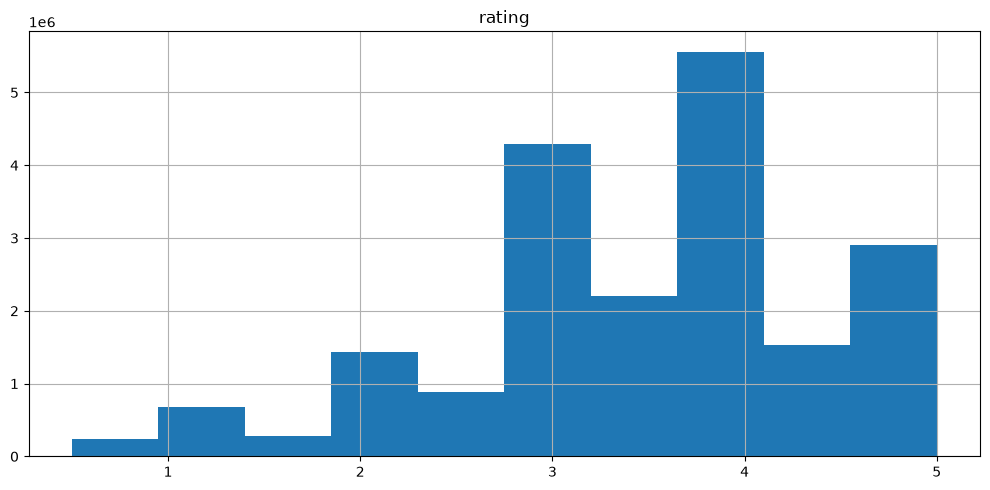

In [42]:
ratings.hist(column="rating", figsize=(10, 5))
plt.tight_layout()
plt.show()

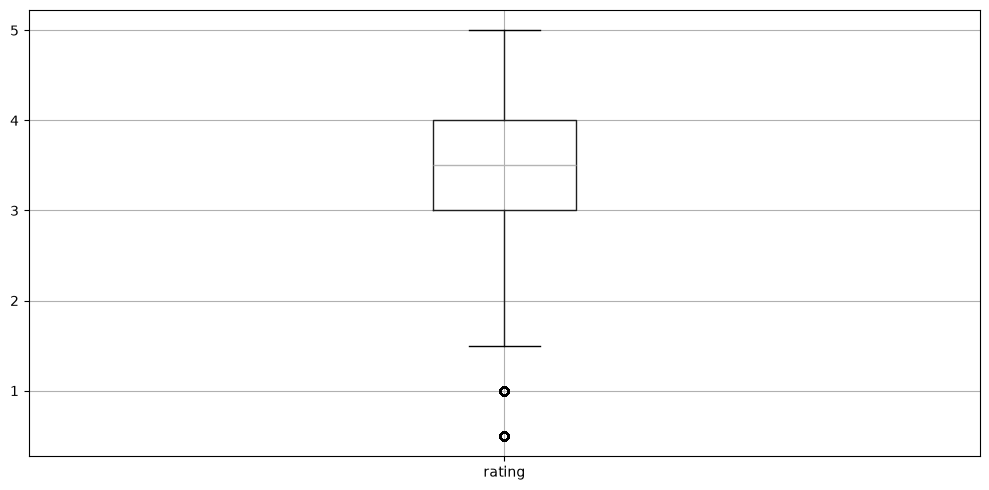

In [43]:
ratings.boxplot(column="rating", figsize=(10, 5))
plt.tight_layout()
plt.show()

## 6. Select columns and inspect values

Use single brackets to select one column and double brackets to select multiple columns. `value_counts()` counts how often each tag appears.


## Slicing Out Columns

In [44]:
tags["tag"].head()

0      Mark Waters
1        dark hero
2        dark hero
3    noir thriller
4        dark hero
Name: tag, dtype: str

In [45]:
movies[["title", "genres"]].head()

,title,genres
0,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,Jumanji (1995),Adventure|Children|Fantasy
2,Grumpier Old Men (1995),Comedy|Romance
3,Waiting to Exhale (1995),Comedy|Drama|Romance
4,Father of the Bride Part II (1995),Comedy


In [46]:
ratings[-10:]

,userId,movieId,rating
20000253,138493,60816,4.5
20000254,138493,61160,4.0
20000255,138493,65682,4.5
20000256,138493,66762,4.5
20000257,138493,68319,4.5
20000258,138493,68954,4.5
20000259,138493,69526,4.5
20000260,138493,69644,3.0
20000261,138493,70286,5.0
20000262,138493,71619,2.5


In [47]:
tag_counts = tags["tag"].value_counts()
tag_counts.tail(10)

tag
Roland JoffÃ©                                                           1
Seu Jorge                                                               1
Michel Audiard                                                          1
French film                                                             1
Clouseau                                                                1
Disguises                                                               1
retarted                                                                1
circle k                                                                1
This movie should have been called \\"How Cocaine Ruined Disney\"\""    1
topless scene                                                           1
Name: count, dtype: int64

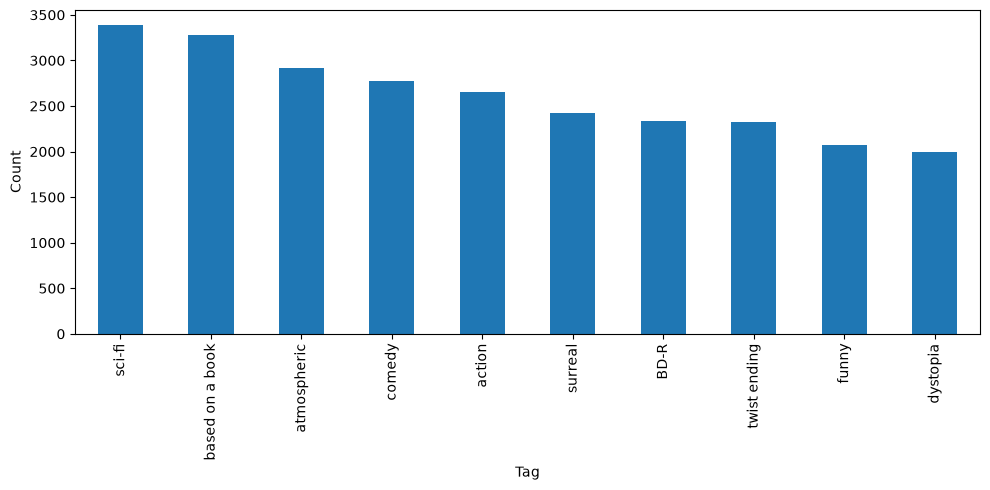

In [48]:
tag_counts.head(10).plot(kind="bar", figsize=(10, 5))
plt.xlabel("Tag")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 7. Filter rows

Boolean conditions select rows that match a rule. These examples select high ratings and movies whose genre text contains `Action`.


## Filters for Selecting Rows

In [49]:
is_highly_rated = ratings["rating"] >= 5.0
ratings[is_highly_rated][30:50]

,userId,movieId,rating
239,3,50,5.0
242,3,175,5.0
244,3,223,5.0
245,3,260,5.0
246,3,316,5.0
247,3,318,5.0
248,3,329,5.0
252,3,457,5.0
253,3,480,5.0
254,3,490,5.0


In [50]:
is_action = movies["genres"].str.contains("Action", na=False)
movies.loc[is_action].iloc[5:15]

,movieId,title,genres
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller
69,70,From Dusk Till Dawn (1996),Action|Comedy|Horror|Thriller
70,71,Fair Game (1995),Action
75,76,Screamers (1995),Action|Sci-Fi|Thriller
77,78,"Crossing Guard, The (1995)",Action|Crime|Drama|Thriller
85,86,White Squall (1996),Action|Adventure|Drama


In [51]:
movies.loc[is_action].head(15)

,movieId,title,genres
5,6,Heat (1995),Action|Crime|Thriller
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller
14,15,Cutthroat Island (1995),Action|Adventure|Romance
19,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller
22,23,Assassins (1995),Action|Crime|Thriller
41,42,Dead Presidents (1995),Action|Crime|Drama
43,44,Mortal Kombat (1995),Action|Adventure|Fantasy
50,51,Guardian Angel (1994),Action|Drama|Thriller
65,66,Lawnmower Man 2: Beyond Cyberspace (1996),Action|Sci-Fi|Thriller


## 8. Group and aggregate

`groupby()` groups rows by a category, and aggregation methods such as `count()` and `mean()` summarize each group.


## Group By and Aggregate

In [52]:
ratings_count = ratings.groupby("rating")[["movieId"]].count()
ratings_count

,movieId
rating,
0.5,239125
1.0,680732
1.5,279252
2.0,1430997
2.5,883398
3.0,4291193
3.5,2200156
4.0,5561926
4.5,1534824


In [53]:
average_rating = ratings.groupby("movieId", as_index=False)["rating"].mean()
average_rating.head()

,movieId,rating
0,1,3.921240
1,2,3.211977
2,3,3.151040
3,4,2.861393
4,5,3.064592


In [54]:
movie_count = ratings.groupby("movieId")[["rating"]].count()
movie_count.head()

,rating
movieId,
1,49695
2,22243
3,12735
4,2756
5,12161


In [55]:
movie_count.tail()

,rating
movieId,
131254,1
131256,1
131258,1
131260,1
131262,1


## 9. Merge DataFrames

`merge()` combines tables using a shared key. In this example, `movieId` connects movie details with tags.


## Merge Dataframes

In [56]:
tags.head()

,userId,movieId,tag,timestamp
0,18,4141,Mark Waters,2009-04-24 18:19:40
1,65,208,dark hero,2013-05-10 01:41:18
2,65,353,dark hero,2013-05-10 01:41:19
3,65,521,noir thriller,2013-05-10 01:39:43
4,65,592,dark hero,2013-05-10 01:41:18


In [57]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [58]:
movies_with_tags = movies.merge(tags, on="movieId", how="inner")
movies_with_tags.head()

,movieId,title,genres,userId,tag,timestamp
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1644,Watched,2014-12-04 23:44:40
1,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,computer animation,2007-07-08 13:59:15
2,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Disney animated feature,2007-07-08 22:21:47
3,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,Pixar animation,2007-07-08 22:46:10
4,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1741,TÃ©a Leoni does not star in this movie,2009-06-15 19:19:33


## 10. Combine grouping, merging, and filtering

This final example calculates each movie's average rating, joins those averages to movie details, and filters for highly rated Adventure movies.


### Combine aggreagation, merging, and filters to get useful analytics

In [59]:
avg_ratings = ratings.groupby("movieId", as_index=False)["rating"].mean()
avg_ratings.head()

,movieId,rating
0,1,3.921240
1,2,3.211977
2,3,3.151040
3,4,2.861393
4,5,3.064592


In [60]:
movie_ratings = movies.merge(avg_ratings, on="movieId", how="inner")
movie_ratings.tail()

,movieId,title,genres,rating
26739,131254,Kein Bund für's Leben (2007),Comedy,4.0
26740,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,4.0
26741,131258,The Pirates (2014),Adventure,2.5
26742,131260,Rentun Ruusu (2001),(no genres listed),3.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


In [61]:
is_highly_rated = movie_ratings["rating"] >= 4.0
movie_ratings.loc[is_highly_rated].tail()

,movieId,title,genres,rating
26737,131250,No More School (2000),Comedy,4.0
26738,131252,Forklift Driver Klaus: The First Day on the Jo...,Comedy|Horror,4.0
26739,131254,Kein Bund für's Leben (2007),Comedy,4.0
26740,131256,"Feuer, Eis & Dosenbier (2002)",Comedy,4.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


In [62]:
is_adventure = movie_ratings["genres"].str.contains("Adventure", na=False)
movie_ratings.loc[is_adventure].head()

,movieId,title,genres,rating
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,3.921240
1,2,Jumanji (1995),Adventure|Children|Fantasy,3.211977
7,8,Tom and Huck (1995),Adventure|Children,3.142049
9,10,GoldenEye (1995),Action|Adventure|Thriller,3.430029
12,13,Balto (1995),Adventure|Animation|Children,3.272416


In [63]:
movie_ratings.loc[is_adventure & is_highly_rated].tail()

,movieId,title,genres,rating
26611,130586,Itinerary of a Spoiled Child (1988),Adventure|Drama,4.5
26655,130996,The Beautiful Story (1992),Adventure|Drama|Fantasy,5.0
26667,131050,Stargate SG-1 Children of the Gods - Final Cut...,Adventure|Sci-Fi|Thriller,5.0
26736,131248,Brother Bear 2 (2006),Adventure|Animation|Children|Comedy|Fantasy,4.0
26743,131262,Innocence (2014),Adventure|Fantasy|Horror,4.0


## Key takeaways

- Use `read_csv()` to load CSV data into DataFrames.
- Use `head()`, `shape`, `columns`, and `iloc` to inspect data.
- Use `describe()`, `mean()`, and `value_counts()` to summarize it.
- Use boolean masks to filter rows.
- Use `groupby()` for grouped calculations and `merge()` to combine related tables.

**Tip:** Run the notebook from top to bottom after confirming that the three CSV files are in the `Datasets` folder.
